# Exploratory Data Analysis
This notebook aims to explore and understand the dataset.

## Table of Contents

* [1. Import Data](#1-import-data)
    * [1.1 Importing Libraries](#11-importing-libraries)
    * [1.2 Importing Data](#12-importing-data)
* [2. Data Structure](#2-data-structure)
    * [2.1 Inspecting Data Structure](#21-insepcting-data-structure)
    * [2.2 Missing Value Checks](#22-missing-value-checks)
    * [2.3 Duplicates & Integrity Checks](#23-duplicates--integrity-checks)
* [3. Univariate Analysis](#3-univariate-analysis)
* [4. Bivariate Analysis](#4-bivariate-analysis)
* [_. Multicollinearity Checks](#_-multicollinearity-checks)


## 1. Import Data

### 1.1 Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import sys
import os

sys.path.append(os.path.abspath(".."))

from src.utils import display_side_by_side


print("loaded")

loaded


### 1.2 Importing Data

In [2]:
df = pd.read_csv("../data/raw_data/insurance_data.csv")

df.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


## 2. Data Structure

We aim to explore the dataset thoroughly in this section. We will manipulate the dataset accordingly, after the analysis, saving the copy the manipulated dataset for future use. 

### 2.1 Insepcting Data Structure

In [3]:
df

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87


In [4]:
df.describe()

,index,PatientID,age,bmi,bloodpressure,children,claim
count,1340.000000,1340.000000,1335.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,669.500000,670.500000,38.078652,30.668955,94.157463,1.093284,13252.745642
std,386.968991,386.968991,11.102924,6.106735,11.434712,1.205334,12109.609288
min,0.000000,1.000000,18.000000,16.000000,80.000000,0.000000,1121.870000
25%,334.750000,335.750000,29.000000,26.275000,86.000000,0.000000,4719.685000
50%,669.500000,670.500000,38.000000,30.400000,92.000000,1.000000,9369.615000
75%,1004.250000,1005.250000,47.000000,34.700000,99.000000,2.000000,16604.305000
max,1339.000000,1340.000000,60.000000,53.100000,140.000000,5.000000,63770.430000


In [5]:
df.describe(include="all")

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1340.000000,1340.000000,1335.000000,1340,1340.000000,1340.000000,1340,1340.000000,1340,1337,1340.000000
unique,NaN,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,NaN,678,NaN,NaN,698,NaN,1066,443,NaN
mean,669.500000,670.500000,38.078652,NaN,30.668955,94.157463,NaN,1.093284,NaN,NaN,13252.745642
std,386.968991,386.968991,11.102924,NaN,6.106735,11.434712,NaN,1.205334,NaN,NaN,12109.609288
min,0.000000,1.000000,18.000000,NaN,16.000000,80.000000,NaN,0.000000,NaN,NaN,1121.870000
25%,334.750000,335.750000,29.000000,NaN,26.275000,86.000000,NaN,0.000000,NaN,NaN,4719.685000
50%,669.500000,670.500000,38.000000,NaN,30.400000,92.000000,NaN,1.000000,NaN,NaN,9369.615000
75%,1004.250000,1005.250000,47.000000,NaN,34.700000,99.000000,NaN,2.000000,NaN,NaN,16604.305000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   str    
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   str    
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   str    
 9   region         1337 non-null   str    
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), str(4)
memory usage: 115.3 KB


The dataset given in this project reflects a claim-level dataset, which each row represents one individual medical claim. The dataset has 1340 observations with 11 variables, `PatientID` being an unique ID and `claim` being the target variable. The datatypes of each variable is given above with `df.info()`. However, it makes more interpretable when `age` to be an integer, rather than a float.

### 2.2 Missing Value Checks

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   str    
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   str    
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   str    
 9   region         1337 non-null   str    
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), str(4)
memory usage: 115.3 KB


Examining the dataset, we see that there are a few missing values in `age` and `region`.

In [8]:
df[df['age'].isna() | df['region'].isna()]

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
5,5,6,NaN,male,34.4,96,Yes,0,No,northwest,1137.47
6,6,7,NaN,male,37.3,86,Yes,0,No,northwest,1141.45
13,13,14,32.0,male,27.6,100,No,0,No,NaN,1252.41
14,14,15,40.0,male,28.7,81,Yes,0,No,NaN,1253.94
15,15,16,32.0,male,30.4,86,Yes,0,No,NaN,1256.30


In [9]:
print(100*df['age'].isna().mean(),"%", 100*df['region'].isna().mean(),"%")

0.3731343283582089 % 0.22388059701492538 %


It looks like the missing values of each `age` and `region` takes up 0.4% and 0.2% of the sample size. Furthermore, although it is difficult to prove that the missing values are completely at random, they seem to be merely data entry errors. Hence, it is safe to drop these observations.

### 2.3 Duplicates & Integrity Checks

In [10]:
len(df['PatientID'].unique())

1340

`PatientID` can be used to see if there are any duplicates. Since unique ID has the same cardinality as the dataset (1340 observations), there are no duplicates present in the dataset.

In [11]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop(['index', 'PatientID'])
categorical_cols = df.select_dtypes(include='str').columns

categorical_cols

Index(['gender', 'diabetic', 'smoker', 'region'], dtype='str')

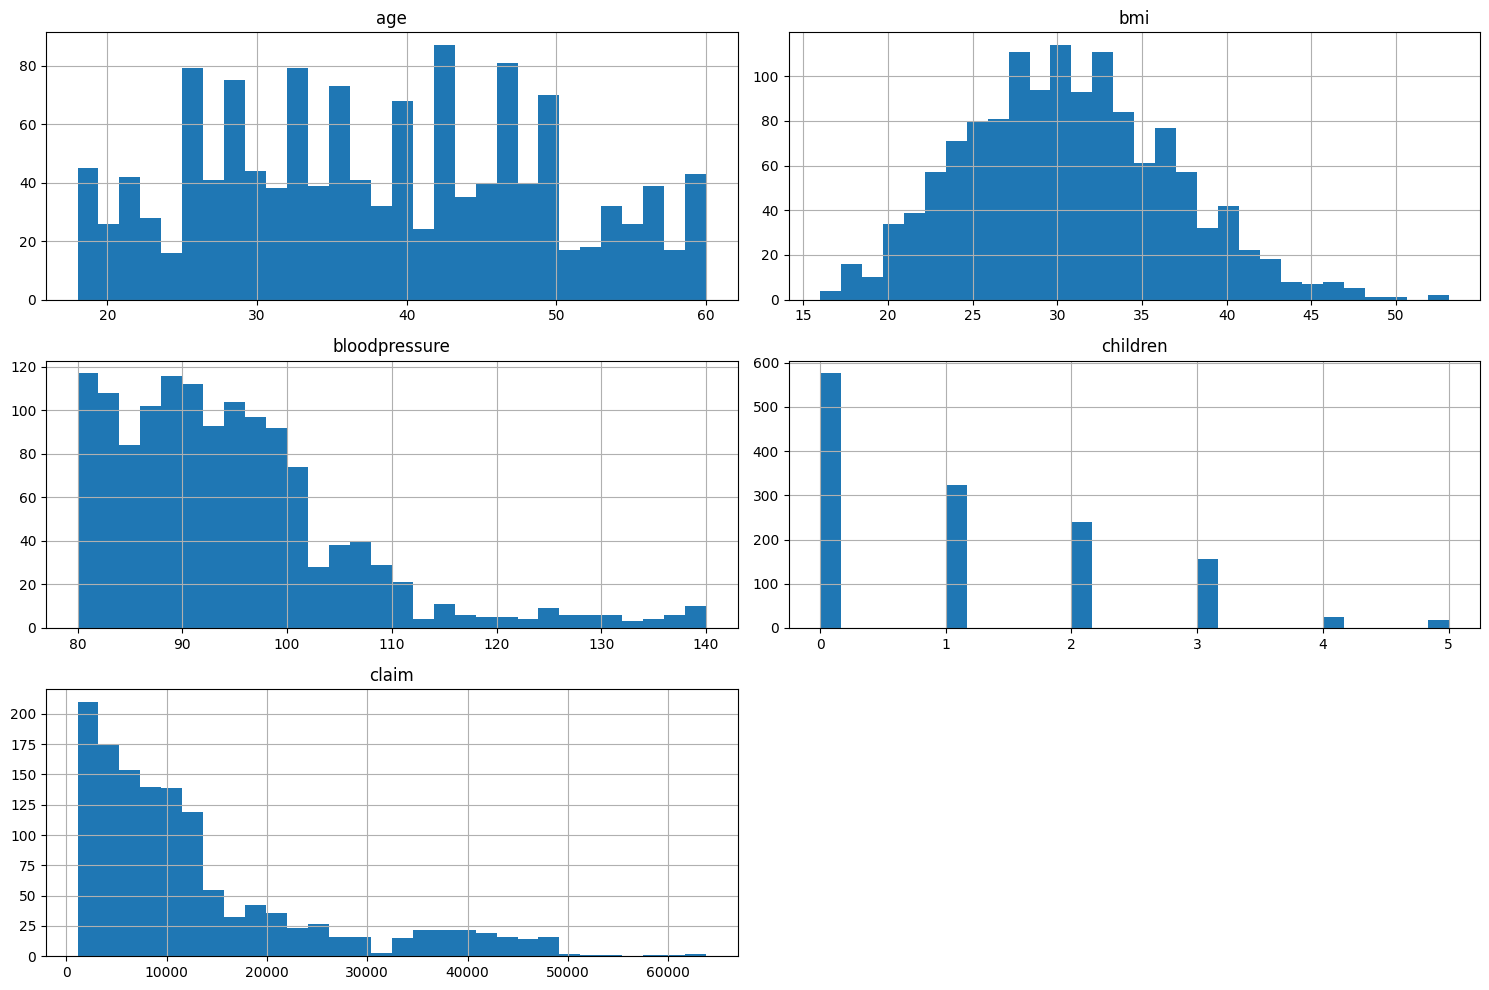

In [12]:
df[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

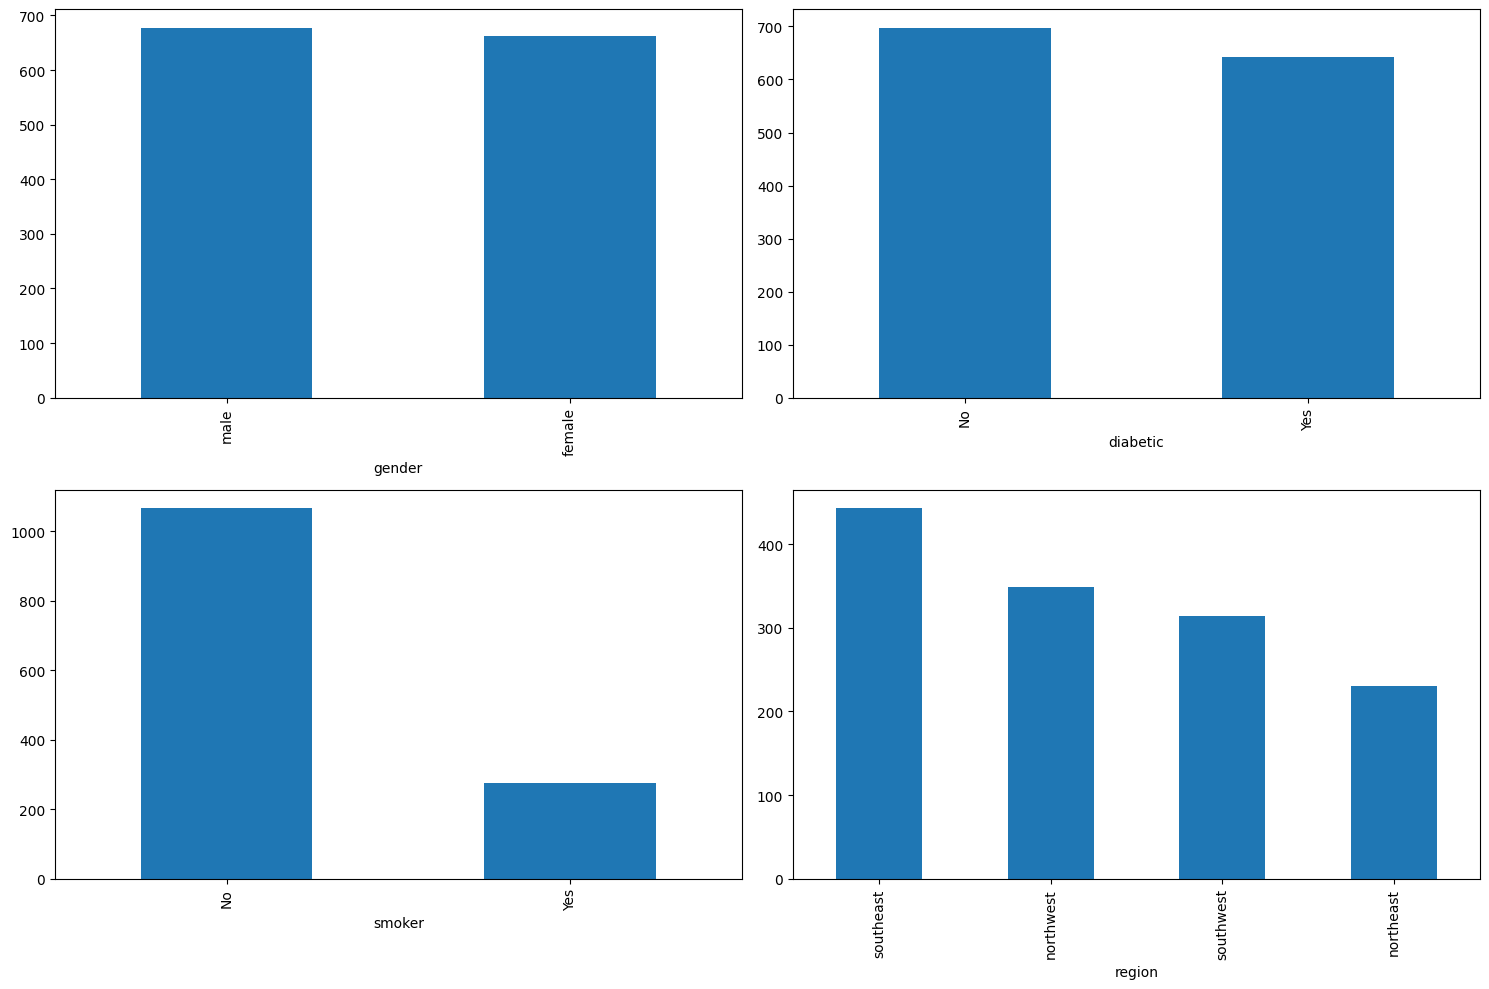

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])

plt.tight_layout()
plt.show()

## 2.4 Data Manipulation

We want to remove observations with null values in `age` and `region`. Additionally, we want to make `age` int type instead of float type.

In [14]:
# Copy for safety
df_man = df.copy()

# Remove observations with null values
df_man = df_man.dropna()

df_man['age'] = df_man['age'].astype('int64')

df_man.info()

<class 'pandas.DataFrame'>
Index: 1332 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1332 non-null   int64  
 1   PatientID      1332 non-null   int64  
 2   age            1332 non-null   int64  
 3   gender         1332 non-null   str    
 4   bmi            1332 non-null   float64
 5   bloodpressure  1332 non-null   int64  
 6   diabetic       1332 non-null   str    
 7   children       1332 non-null   int64  
 8   smoker         1332 non-null   str    
 9   region         1332 non-null   str    
 10  claim          1332 non-null   float64
dtypes: float64(2), int64(5), str(4)
memory usage: 124.9 KB


We can see that the number of non-null observations are 1332 which is 8 less than the original number of observations, 1340. We can also see that the Dtype of `age` is now integer.

In [15]:
df_man.to_csv("../data/processed/insurance_data_cleaned.csv", index=False)

## 3. Univariate Analysis

Recall that: 
* Numerical Risk Factors:
    - age
    - bmi
    - bloodpressure
    - children
* Categorical Risk Factors:
    - gender
    - diabetic
    - smoker
    - region
* Target variable:
    - claim

### 3.1 Target Variable

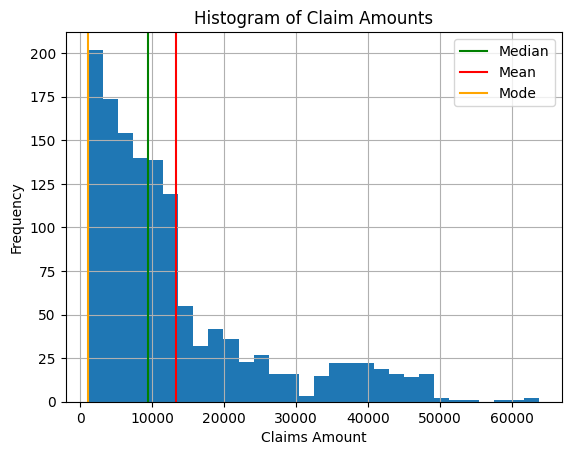

In [16]:
# Central Tendencies
claim_mean = df_man['claim'].mean()
claim_median = df_man['claim'].median()
claim_mode = df_man['claim'].mode()[0]
claim_var = df_man['claim'].var()

df_man['claim'].hist(bins=30)
plt.axvline(claim_median, color='green', label='Median')
plt.axvline(claim_mean, color='red', label = 'Mean')
plt.axvline(claim_mode, color='orange', label = 'Mode')
plt.xlabel("Claims Amount")
plt.ylabel("Frequency")
plt.title("Histogram of Claim Amounts")
plt.legend()
plt.show()

In [17]:
print('Mean^2: ', claim_mean**2,"Variance: ", claim_var)

Mean^2:  177562192.32499027 Variance:  146642913.79497415


The claim distribution exhibits strong positive skewness. The mean substantially exceeds the median, indicating sensitivity to high-cost claims. The majority of observations are present below $15,000, while a small subset extends beyond $50,000. Additionally, the mean and the variance of claims amount is given above. This heavy-tailed behaviour is characteristic of insurance severity data. It is necessary to check the appropriateness of a Gamma (or Lognormal) distribution with log link function.

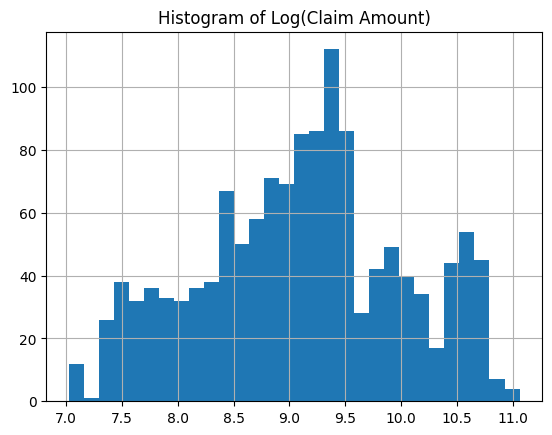

In [18]:
np.log(df_man['claim']).hist(bins=30)
plt.title("Histogram of Log(Claim Amount)")
plt.show()

The reduction in skewness under log transformation suggests that it supports the use of a positive-support GLM with log link, such as Gamma.

**Summary**:
* Mean $\approx$ 13,325
* Median $\approx$ 9,413
* Std $\approx$ 12,110
* Range: 1,121 - 63,770
* 75th percentile $\approx$ 16,781

**Interpretation**
* Mean > median $\Rightarrow$ right skew
* Std nearly as large as mean $\Rightarrow$ high dispersion
* Large gap between 75th percentile and max $\Rightarrow$ heavy tail

Given the coefficient of variation: $$\frac{\text{std}}{\text{mean}} = \frac{12110}{13325} \approx 0.91$$ The claim distribution exhibits strong positive skewness with mean exceeding median and substantial dispersion. The larger upper tail suggests multiplicative variability, supporting a Gamma GLM with log link function as a plausible modeling framework. 

### 3.2 Numerical Risk Factors

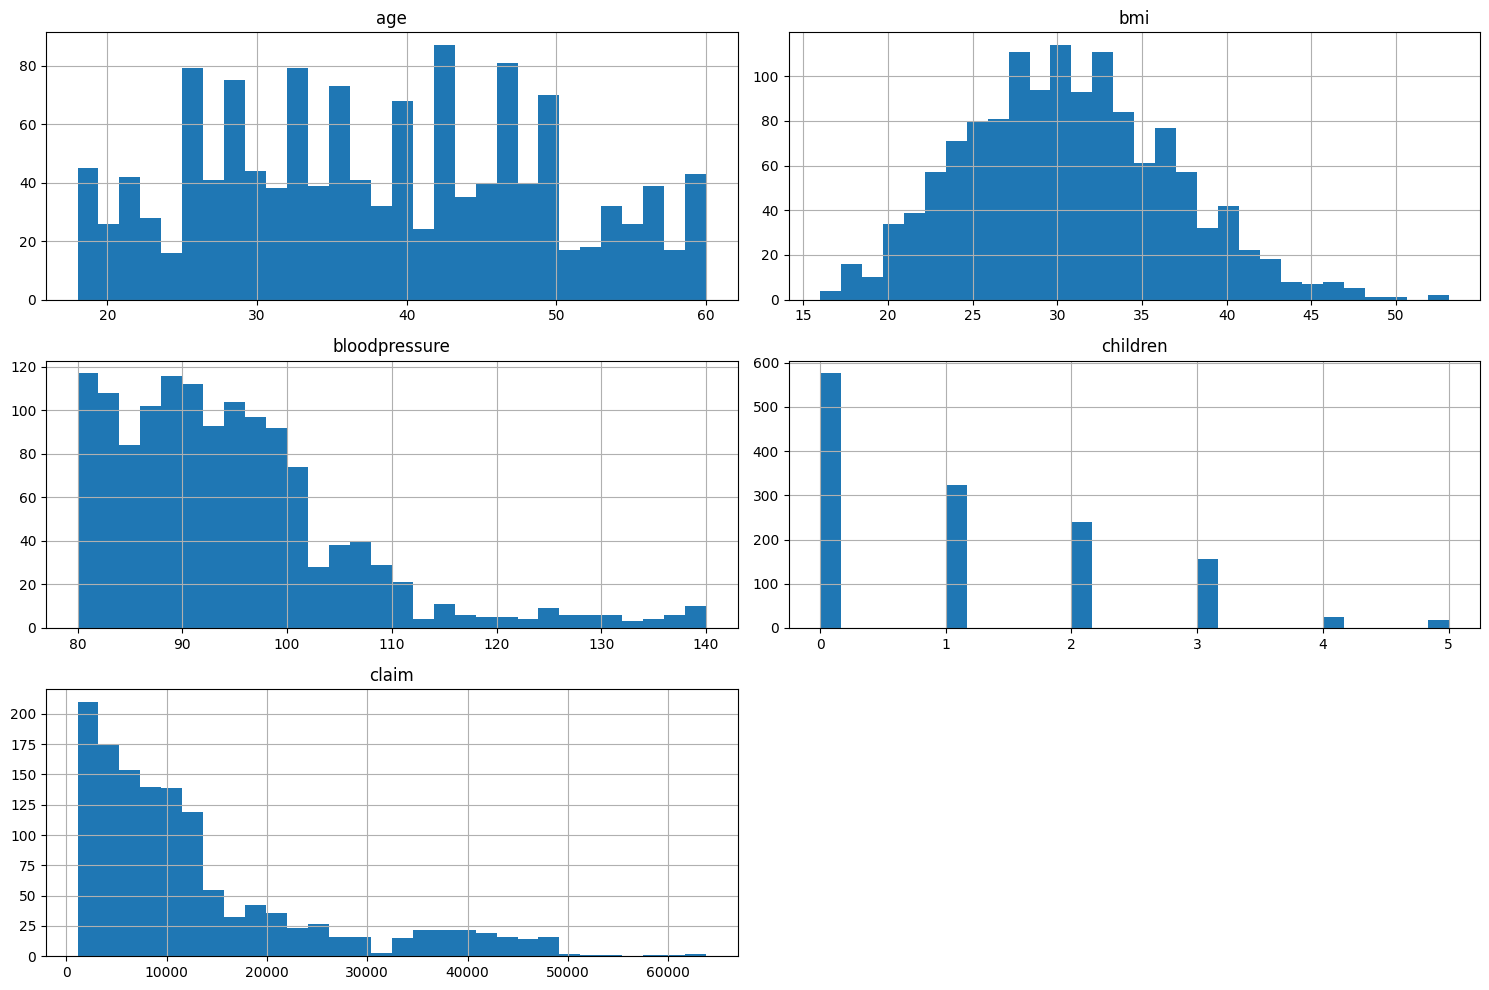

In [19]:
df[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

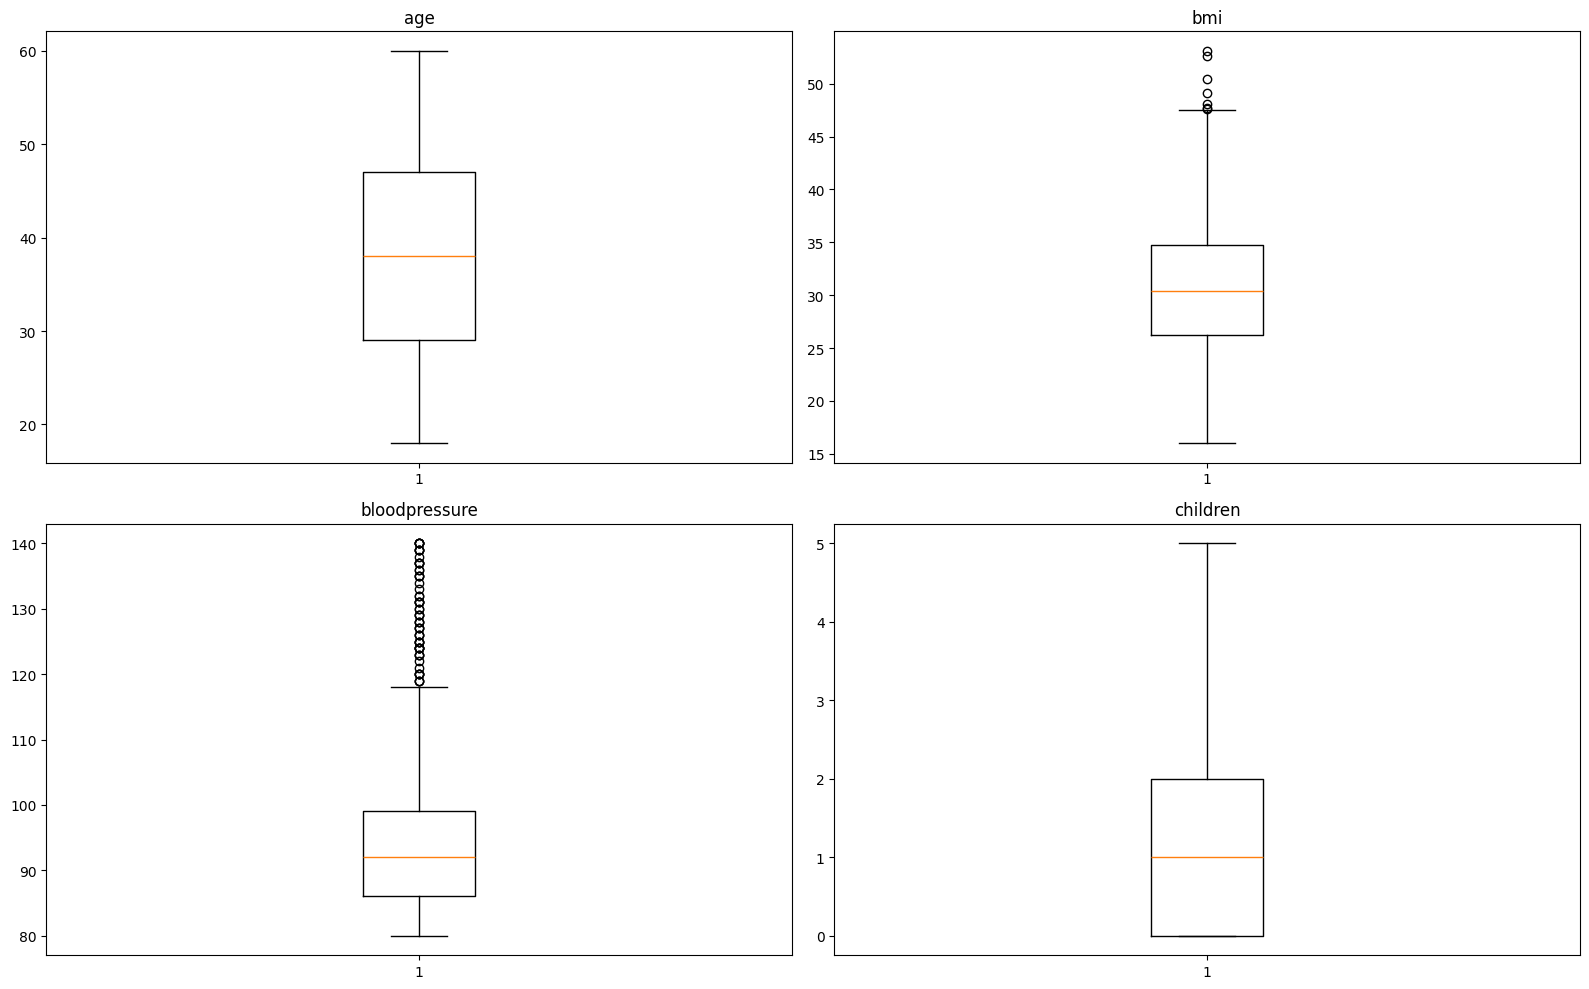

In [26]:
numerical_cols_small = numerical_cols.copy().drop("claim")

fig, axes = plt.subplots(2,2, figsize=(16,10))

axes = axes.flatten()

for i, col in enumerate(numerical_cols_small):
    axes[i].boxplot(df_man[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [ ]:
df_man[numerical_cols].describe()

,age,bmi,bloodpressure,children,claim
count,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000
mean,38.086336,30.658333,94.189189,1.099850,13325.246426
std,11.112804,6.118967,11.445173,1.205958,12109.620712
min,18.000000,16.000000,80.000000,0.000000,1121.870000
25%,29.000000,26.200000,86.000000,0.000000,4760.157500
50%,38.000000,30.350000,92.000000,1.000000,9412.965000
75%,47.000000,34.725000,99.000000,2.000000,16781.327500
max,60.000000,53.100000,140.000000,5.000000,63770.430000


#### 3.2.1. Age

**Summary**:
* Mean $\approx$ 38
* Std $\approx$ 11.1
* Range: 18 - 60

**Interpretation**:
* Fairly good spread across adult population
* No unrealistic values
* median $\approx$ mean $\Rightarrow$ roughly symmetric
* No extreme outliers


#### 3.2.2 BMI

**Summary**:
* Mean $\approx$ 30.7
* Std $\approx$ 6.1
* Range: 16 - 53

**Interpretation**:
* Mean around 30 $\Rightarrow$ this dataset consists of obese individuals, which can cause selection bias
* Distribution looks roughly bell-shaped (normally distributed)
* Right tail slightly extended
* High BMI is usually associated with chronic disease and thus higher medical utilization $\Rightarrow$ This might be a strong candidate predictor for severity

#### 3.2.3 Blood Pressure

**Summary**:
* Mean $\approx$ 94
* Std $\approx$ 11.4
* Range: 80 - 94
* Slight right skew

**Interpretation**:
* Distribution declines toward higher values
    * May need to take a look at relationship between BMI and blood pressure
* One thing to note is that the data might have been truncated because the lower bound is very cleanly cut
* Although it seems to have many outliers, as shown in the boxplot, we will keep these because these may carry important information for claim severity.

#### 3.2.4 Children
**Summary**:
* Mean $\approx$ 1.1
* Std $\approx$ 1.2
* Median $\approx$ 1.0
* Range: 0-5

**Interpretation**
* Many individuals have no children
* Distribution is highly discrete
* Since range is small, categorical modeling might be better for this factor

### 3.3 Categorical Risk Factors

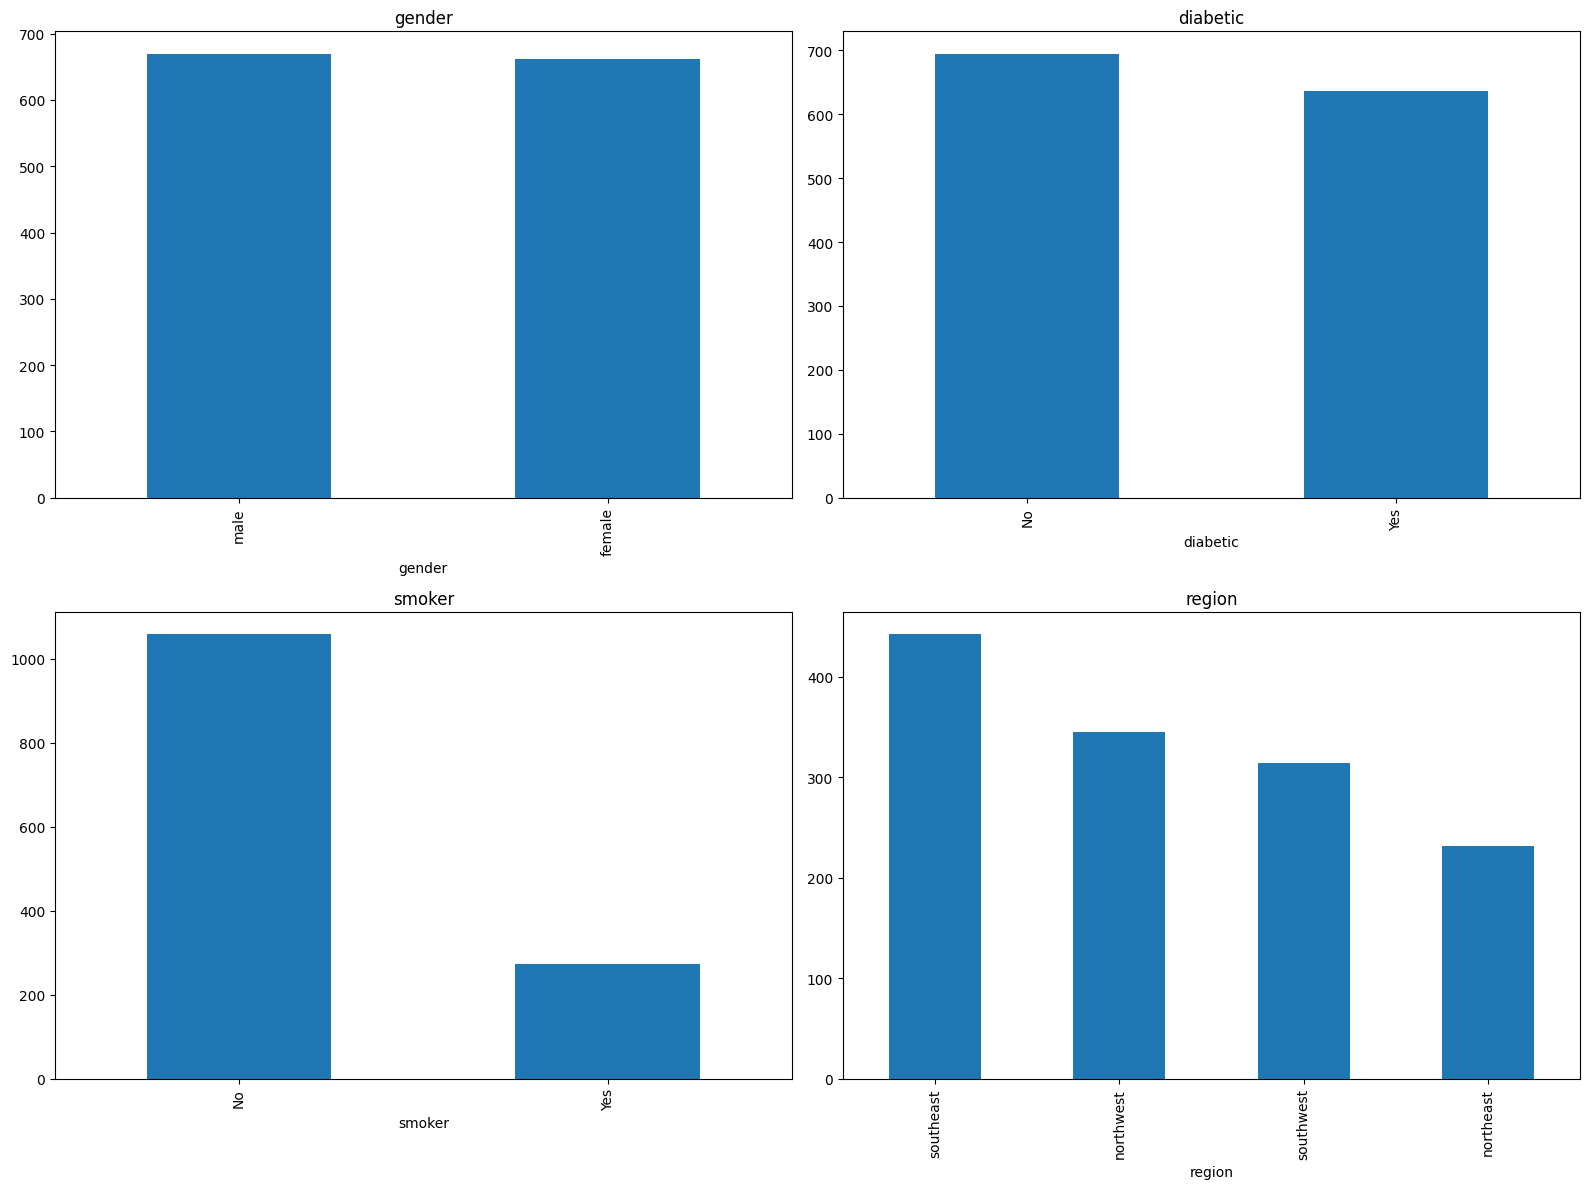

In [31]:
fig, axes = plt.subplots(2,2, figsize=(16,12))

axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df_man[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

#### 3.3.1 Gender

**Interpretation**:
* No class imbalance
* Good representation for male and female

#### 3.3.2 Diabetic
**Interpretation**:
* Slight imbalance, but reasonable
* Not too rare $\Rightarrow$ still reliable for modeling

**Modeling Implication**:
* This is a clinical risk indicator
    * Thus, strong candidate for severity modeling

#### 3.3.3 Smoker
**Interpretation**:
* Strong imbalance $\Rightarrow$ majority non-smokers
* Small smoker group, but not too small
* Likely the most important variable

**Modeling Implication**:
* High explanatory power expected
* Watch for strong coefficient in GLM

#### 3.3.4 Region

**Interpretation**:
* Moderate imbalance
* Still usable

**Actuarial Insight**:
* Captures geographic variation:
    * healthcare cost differences
    * lifestyle differences

The categorical variables exhibi generally well-balanced distributions across gender and region, while the smoker and diabetic indicators are moderately imbalanced. In particular, the smoker variable shows a smaller high-risk subgoup, which is expected to have a strong impact on claim severity. overall, the distributions are suitable for modeling without requiring category aggregation.

## 4. Bivariate Analysis

## _. Multicollinearity Checks